<a href="https://colab.research.google.com/github/andhykavireza/tugas-3-kecerdasan-buatan/blob/main/Tugas_4_Fuzzy_SCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Melatih Model Fuzzy Sederhana...


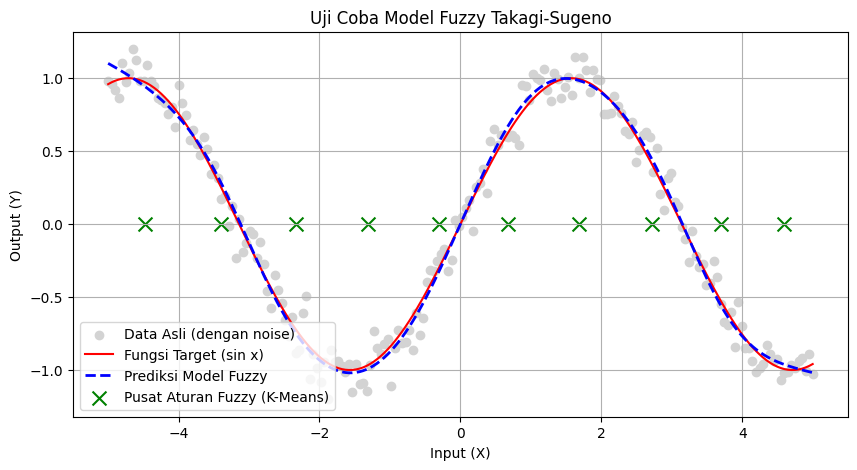

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

class FSCN:
    def __init__(self, K=5):
        """
        K = Jumlah aturan fuzzy (cluster)
        """
        self.K = K
        self.centers = None
        self.p_k = None
        self.beta = None

    def _calc_fuzzy_layer(self, X):
        """Langkah 2: Menghitung output dari Aturan Fuzzy T-S (Matriks H0)"""
        N, d = X.shape
        mu = np.zeros((N, d, self.K))

        # Hitung derajat keanggotaan Gaussian
        for k in range(self.K):
            for i in range(d):
                #Lebar (sigma) disetel statis ke 1.0
                mu[:, i, k] = np.exp(-((X[:, i] - self.centers[k, i]) / 1.0)**2)

        # Hitung fire strength (perkalian probabilitas antar dimensi)
        omega = np.prod(mu, axis=1)

        # Normalisasi fire strength
        omega_sum = np.sum(omega, axis=1, keepdims=True) + 1e-8
        omega_tilde = omega / omega_sum

        # Hitung consequent (Bagian linear dari Takagi-Sugeno)
        H0 = np.zeros((N, self.K))
        for k in range(self.K):
            consequent = np.sum(self.p_k[k, :] * X, axis=1)
            H0[:, k] = omega_tilde[:, k] * consequent

        return H0

    def fit(self, X, Y):
        """Langkah 1 & 3: Latih Model"""
        # 1. Tentukan pusat fuzzy menggunakan K-Means++
        kmeans = KMeans(n_clusters=self.K, init='k-means++', n_init=10, random_state=42)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_

        # Inisialisasi faktor acak untuk consequent T-S
        self.p_k = np.random.randn(self.K, X.shape[1])

        # 2. Proses data melalui layer fuzzy
        H0 = self._calc_fuzzy_layer(X)

        # 3. Cari bobot output akhir (beta) menggunakan Pseudo-Inverse (Least Squares)
        lambd = 1e-5 # Regularisasi kecil agar stabil
        self.beta = np.linalg.pinv(H0.T @ H0 + lambd * np.eye(self.K)) @ H0.T @ Y

    def predict(self, X):
        """Prediksi data baru"""
        H0 = self._calc_fuzzy_layer(X)
        return np.dot(H0, self.beta)


# DATA DUMMY

# 1. Buat data dummy (Fungsi Nonlinear Sederhana: y = sin(x) + sedikit noise)
X_data = np.linspace(-5, 5, 200).reshape(-1, 1)
Y_data = np.sin(X_data) + np.random.normal(0, 0.1, (200, 1))

# 2. Latih Model Fuzzy dengan 10 aturan (K=10)
print("Melatih Model Fuzzy Sederhana...")
model = FSCN(K=10)
model.fit(X_data, Y_data)

# 3. Lakukan Prediksi
Y_pred = model.predict(X_data)

# 4. Visualisasikan Hasil
plt.figure(figsize=(10, 5))
plt.scatter(X_data, Y_data, color='lightgray', label='Data Asli (dengan noise)')
plt.plot(X_data, np.sin(X_data), color='red', label='Fungsi Target (sin x)')
plt.plot(X_data, Y_pred, color='blue', linewidth=2, linestyle='--', label='Prediksi Model Fuzzy')

# Tampilkan letak titik pusat dari cluster fuzzy di sumbu X
plt.scatter(model.centers, np.zeros_like(model.centers), color='green', marker='x', s=100, label='Pusat Aturan Fuzzy (K-Means)')

plt.title("Uji Coba Model Fuzzy Takagi-Sugeno")
plt.xlabel("Input (X)")
plt.ylabel("Output (Y)")
plt.legend()
plt.grid(True)
plt.show()